In [94]:
financial_summary = {
    'Total Revenue ($)':           fact_orders['revenue_generated'].sum(),
    'Total Profit ($)':            fact_orders['profit'].sum(),
    'Avg Gross Margin (%)':        (fact_orders['profit'].sum() / fact_orders['revenue_generated'].sum()) * 100,
    'Avg Customer Satisfaction':   fact_orders['customer_satisfaction_score'].mean()
}

for metric, value in financial_summary.items():
    if '%' in metric:
        print(f"  {metric}: {value:.2f}%")
    elif 'Satisfaction' in metric:
        print(f"  {metric}: {value:.2f} / 5.00")
    else:
        print(f"  {metric}: ${value:,.2f}")

  Total Revenue ($): $182,806,227.83
  Total Profit ($): $97,560,290.06
  Avg Gross Margin (%): 53.37%
  Avg Customer Satisfaction: 3.28 / 5.00


# **Supply Chain Analytics Project**
## **Objective**

Analyze an electronics supply chain dataset to evaluate financial, inventory, supplier, and logistics performance using Python, SQL, and Tableau.

# ***Phase 1 :***
> **Data Cleaning and Preprocessing**

###Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###Load Dataset

In [27]:
pd.read_csv("/content/electronicsSupplyChain.csv")

,Order ID,Order Date,Ship Date,Delivery Date,Product type,SKU,Category,Price,Discount (%),Price_After_Discount,...,Shipping costs,On-Time Delivery,Supplier name,Supplier Reliability Score,Manufacturing costs,Quality Score,Defect rates,Production volumes,Carrier Name,Transportation Mode
0,ORD1000,19/06/2022,23/06/2022,28/06/2022,Smartphones,SKU0000,Premium,"1,159.56",13.92,998.15,...,38.07,Yes,Supplier 5,0.61,477.03,23.11,7.69,1084,DHL,Road
1,ORD1001,30/03/2022,31/03/2022,11/04/2022,Tablets,SKU0001,Premium,750.06,4.16,718.86,...,271.81,Yes,Supplier 4,0.75,271.63,84.46,1.55,372,OnTrac,Air
2,ORD1002,02/02/2023,04/02/2023,14/02/2023,Laptops,SKU0002,Premium,"1,867.08",14.90,"1,588.89",...,327.91,Yes,Supplier 2,0.66,969.25,14.26,8.57,558,DHL,Air
3,ORD1003,03/03/2023,04/03/2023,07/03/2023,Smartwatches,SKU0003,Premium,361.14,9.73,326.00,...,250.00,Yes,Supplier 5,0.62,131.04,73.61,2.64,537,DHL,Air
4,ORD1004,25/06/2024,30/06/2024,06/07/2024,Laptops,SKU0004,Premium,"2,067.20",11.38,"1,831.95",...,28.43,Yes,Supplier 3,0.67,"1,132.55",59.59,4.04,1109,FedEx,Road
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,ORD2495,07/04/2024,10/04/2024,22/04/2024,Smartwatches,SKU1495,Mid-Range,307.63,6.63,287.23,...,648.91,No,Supplier 3,0.75,115.37,64.69,3.53,679,OnTrac,Air
1496,ORD2496,22/09/2024,23/09/2024,24/09/2024,Smartphones,SKU1496,Premium,761.92,5.40,720.78,...,5.01,Yes,Supplier 1,0.66,261.61,52.57,4.74,649,FedEx,Road
1497,ORD2497,18/06/2024,21/06/2024,27/06/2024,Laptops,SKU1497,Premium,"1,797.29",8.57,"1,643.26",...,336.44,No,Supplier 2,0.87,633.64,82.48,1.75,572,UPS,Air
1498,ORD2498,21/07/2022,26/07/2022,28/07/2022,Headphones,SKU1498,Budget,57.14,1.47,56.30,...,124.33,Yes,Supplier 2,0.40,25.53,0.65,9.94,507,FedEx,Sea


In [28]:
df = pd.read_csv("/content/electronicsSupplyChain.csv")

In [29]:
df.head()

,Order ID,Order Date,Ship Date,Delivery Date,Product type,SKU,Category,Price,Discount (%),Price_After_Discount,...,Shipping costs,On-Time Delivery,Supplier name,Supplier Reliability Score,Manufacturing costs,Quality Score,Defect rates,Production volumes,Carrier Name,Transportation Mode
0,ORD1000,19/06/2022,23/06/2022,28/06/2022,Smartphones,SKU0000,Premium,"1,159.56",13.92,998.15,...,38.07,Yes,Supplier 5,0.61,477.03,23.11,7.69,1084,DHL,Road
1,ORD1001,30/03/2022,31/03/2022,11/04/2022,Tablets,SKU0001,Premium,750.06,4.16,718.86,...,271.81,Yes,Supplier 4,0.75,271.63,84.46,1.55,372,OnTrac,Air
2,ORD1002,02/02/2023,04/02/2023,14/02/2023,Laptops,SKU0002,Premium,"1,867.08",14.90,"1,588.89",...,327.91,Yes,Supplier 2,0.66,969.25,14.26,8.57,558,DHL,Air
3,ORD1003,03/03/2023,04/03/2023,07/03/2023,Smartwatches,SKU0003,Premium,361.14,9.73,326.00,...,250.00,Yes,Supplier 5,0.62,131.04,73.61,2.64,537,DHL,Air
4,ORD1004,25/06/2024,30/06/2024,06/07/2024,Laptops,SKU0004,Premium,"2,067.20",11.38,"1,831.95",...,28.43,Yes,Supplier 3,0.67,"1,132.55",59.59,4.04,1109,FedEx,Road


###Dataset Overview

In [30]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1500
Columns: 35


In [31]:
df.shape

(1500, 35)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Order ID                     1500 non-null   object 
 1   Order Date                   1500 non-null   object 
 2   Ship Date                    1500 non-null   object 
 3   Delivery Date                1500 non-null   object 
 4   Product type                 1500 non-null   object 
 5   SKU                          1500 non-null   object 
 6   Category                     1500 non-null   object 
 7   Price                        1500 non-null   float64
 8   Discount (%)                 1500 non-null   float64
 9   Price_After_Discount         1500 non-null   float64
 10  Number of products sold      1500 non-null   int64  
 11  Units Returned               1500 non-null   int64  
 12  Return Reason                1460 non-null   object 
 13  Revenue generated 

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,"1,500.00",514.66,474.29,20.61,172.28,370.56,707.33,"2,499.95"
Discount (%),"1,500.00",7.55,4.37,0.01,3.69,7.66,11.28,15.00
Price_After_Discount,"1,500.00",475.70,439.24,18.52,158.62,342.37,655.04,"2,467.95"
Number of products sold,"1,500.00",250.11,142.96,10.00,126.00,246.00,375.00,498.00
Units Returned,"1,500.00",18.37,16.44,0.00,5.00,14.00,27.00,73.00
Revenue generated,"1,500.00","121,870.82","154,210.19",483.66,"27,001.68","65,848.90","150,822.12","1,178,622.28"
Profit,"1,500.00","65,040.19","82,770.16",79.30,"13,868.99","35,076.37","81,161.19","745,342.59"
Customer Satisfaction Score,"1,500.00",3.28,1.03,1.20,2.40,3.30,4.20,5.00
Stock levels,"1,500.00",153.94,80.77,20.00,85.00,152.00,221.00,299.00
Reorder Point,"1,500.00",193.87,139.76,3.00,81.00,166.00,279.00,694.00


In [34]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Delivery Date', 'Product type',
       'SKU', 'Category', 'Price', 'Discount (%)', 'Price_After_Discount',
       'Number of products sold', 'Units Returned', 'Return Reason',
       'Revenue generated', 'Profit', 'Customer Satisfaction Score',
       'Customer demographics', 'Sales Channel', 'Payment Method', 'Region',
       'Stock levels', 'Reorder Point', 'Stockout Risk', 'Lead time',
       'Shipping times', 'Shipping costs', 'On-Time Delivery', 'Supplier name',
       'Supplier Reliability Score', 'Manufacturing costs', 'Quality Score',
       'Defect rates', 'Production volumes', 'Carrier Name',
       'Transportation Mode'],
      dtype='object')

###Data Cleaning

####Missing Values

In [35]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Delivery Date,0
Product type,0
SKU,0
Category,0
Price,0
Discount (%),0
Price_After_Discount,0


In [36]:
df['Return Reason'] = df['Return Reason'].fillna("Not Returned")

In [37]:
print(df.isnull().sum())

Order ID                       0
Order Date                     0
Ship Date                      0
Delivery Date                  0
Product type                   0
SKU                            0
Category                       0
Price                          0
Discount (%)                   0
Price_After_Discount           0
Number of products sold        0
Units Returned                 0
Return Reason                  0
Revenue generated              0
Profit                         0
Customer Satisfaction Score    0
Customer demographics          0
Sales Channel                  0
Payment Method                 0
Region                         0
Stock levels                   0
Reorder Point                  0
Stockout Risk                  0
Lead time                      0
Shipping times                 0
Shipping costs                 0
On-Time Delivery               0
Supplier name                  0
Supplier Reliability Score     0
Manufacturing costs            0
Quality Sc

####Duplicate Records

In [38]:
print(df.duplicated().sum())
print("No duplicate records found")

0
No duplicate records found


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Order ID                     1500 non-null   object 
 1   Order Date                   1500 non-null   object 
 2   Ship Date                    1500 non-null   object 
 3   Delivery Date                1500 non-null   object 
 4   Product type                 1500 non-null   object 
 5   SKU                          1500 non-null   object 
 6   Category                     1500 non-null   object 
 7   Price                        1500 non-null   float64
 8   Discount (%)                 1500 non-null   float64
 9   Price_After_Discount         1500 non-null   float64
 10  Number of products sold      1500 non-null   int64  
 11  Units Returned               1500 non-null   int64  
 12  Return Reason                1500 non-null   object 
 13  Revenue generated 

####Data Type Conversion

In [40]:
column_dates = ['Order Date','Ship Date','Delivery Date']
for col in column_dates:
  df[col] = pd.to_datetime(df[col])

/tmp/ipykernel_683/2983624892.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col])
/tmp/ipykernel_683/2983624892.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col])
/tmp/ipykernel_683/2983624892.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col])


In [41]:
text_columns = ['Product type','Category','Return Reason','Customer demographics','Sales Channel','Payment Method','Region','Stockout Risk','On-Time Delivery','Carrier Name','Supplier name','Transportation Mode']

####Data Formatting

In [42]:
for col in text_columns:
   df[col] = df[col].astype(str).str.strip().str.title()

In [43]:
df['SKU'] = df['SKU'].astype(str).str.strip().str.upper()

In [44]:
pd.options.display.float_format = '{:,.2f}'.format

####Column Name Standardization

In [45]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
    .str.replace('(%)', 'pct', regex=False)
)

In [46]:
carrier_fixes = {
    'Dhl': 'DHL',
    'Ups': 'UPS',
    'Usps': 'USPS',
    'Fedex': 'FedEx',
    'Ontrac': 'OnTrac'
}

df['carrier_name'] = df['carrier_name'].replace(carrier_fixes)

In [47]:
df.head()

,order_id,order_date,ship_date,delivery_date,product_type,sku,category,price,discount_pct,price_after_discount,...,shipping_costs,on_time_delivery,supplier_name,supplier_reliability_score,manufacturing_costs,quality_score,defect_rates,production_volumes,carrier_name,transportation_mode
0,ORD1000,2022-06-19,2022-06-23,2022-06-28,Smartphones,SKU0000,Premium,"1,159.56",13.92,998.15,...,38.07,Yes,Supplier 5,0.61,477.03,23.11,7.69,1084,DHL,Road
1,ORD1001,2022-03-30,2022-03-31,2022-04-11,Tablets,SKU0001,Premium,750.06,4.16,718.86,...,271.81,Yes,Supplier 4,0.75,271.63,84.46,1.55,372,OnTrac,Air
2,ORD1002,2023-02-02,2023-02-04,2023-02-14,Laptops,SKU0002,Premium,"1,867.08",14.90,"1,588.89",...,327.91,Yes,Supplier 2,0.66,969.25,14.26,8.57,558,DHL,Air
3,ORD1003,2023-03-03,2023-03-04,2023-03-07,Smartwatches,SKU0003,Premium,361.14,9.73,326.00,...,250.00,Yes,Supplier 5,0.62,131.04,73.61,2.64,537,DHL,Air
4,ORD1004,2024-06-25,2024-06-30,2024-07-06,Laptops,SKU0004,Premium,"2,067.20",11.38,"1,831.95",...,28.43,Yes,Supplier 3,0.67,"1,132.55",59.59,4.04,1109,FedEx,Road


In [48]:
df['is_on_time'] = df['on_time_delivery'].apply(lambda x: 1 if x == 'Yes' else 0)

# ***Exploratory Data Analysis***
> **EDA**

Exploratory Data Analysis (EDA) was performed to understand the dataset, identify patterns and relationships, examine variable distributions, and generate insights before data modeling and visualization.

## Dataset Summary

First, we explored the overall structure of the dataset to understand its size, data types, and statistical characteristics.

In [49]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

display(df.describe().T)

Number of Rows: 1500
Number of Columns: 36


,count,mean,min,25%,50%,75%,max,std
order_date,1500,2023-07-04 22:18:14.399999744,2022-01-01 00:00:00,2022-09-29 00:00:00,2023-07-12 00:00:00,2024-04-06 00:00:00,2024-12-31 00:00:00,NaN
ship_date,1500,2023-07-07 22:49:55.200000,2022-01-02 00:00:00,2022-10-02 12:00:00,2023-07-16 12:00:00,2024-04-08 00:00:00,2025-01-03 00:00:00,NaN
delivery_date,1500,2023-07-14 21:07:12,2022-01-05 00:00:00,2022-10-10 18:00:00,2023-07-24 12:00:00,2024-04-17 00:00:00,2025-01-10 00:00:00,NaN
price,"1,500.00",514.66,20.61,172.28,370.56,707.33,"2,499.95",474.29
discount_pct,"1,500.00",7.55,0.01,3.69,7.66,11.28,15.00,4.37
price_after_discount,"1,500.00",475.70,18.52,158.62,342.37,655.04,"2,467.95",439.24
number_of_products_sold,"1,500.00",250.11,10.00,126.00,246.00,375.00,498.00,142.96
units_returned,"1,500.00",18.37,0.00,5.00,14.00,27.00,73.00,16.44
revenue_generated,"1,500.00","121,870.82",483.66,"27,001.68","65,848.90","150,822.12","1,178,622.28","154,210.19"
profit,"1,500.00","65,040.19",79.30,"13,868.99","35,076.37","81,161.19","745,342.59","82,770.16"


## Correlation Analysis

A correlation matrix was created to identify relationships between numerical variables and support feature analysis.

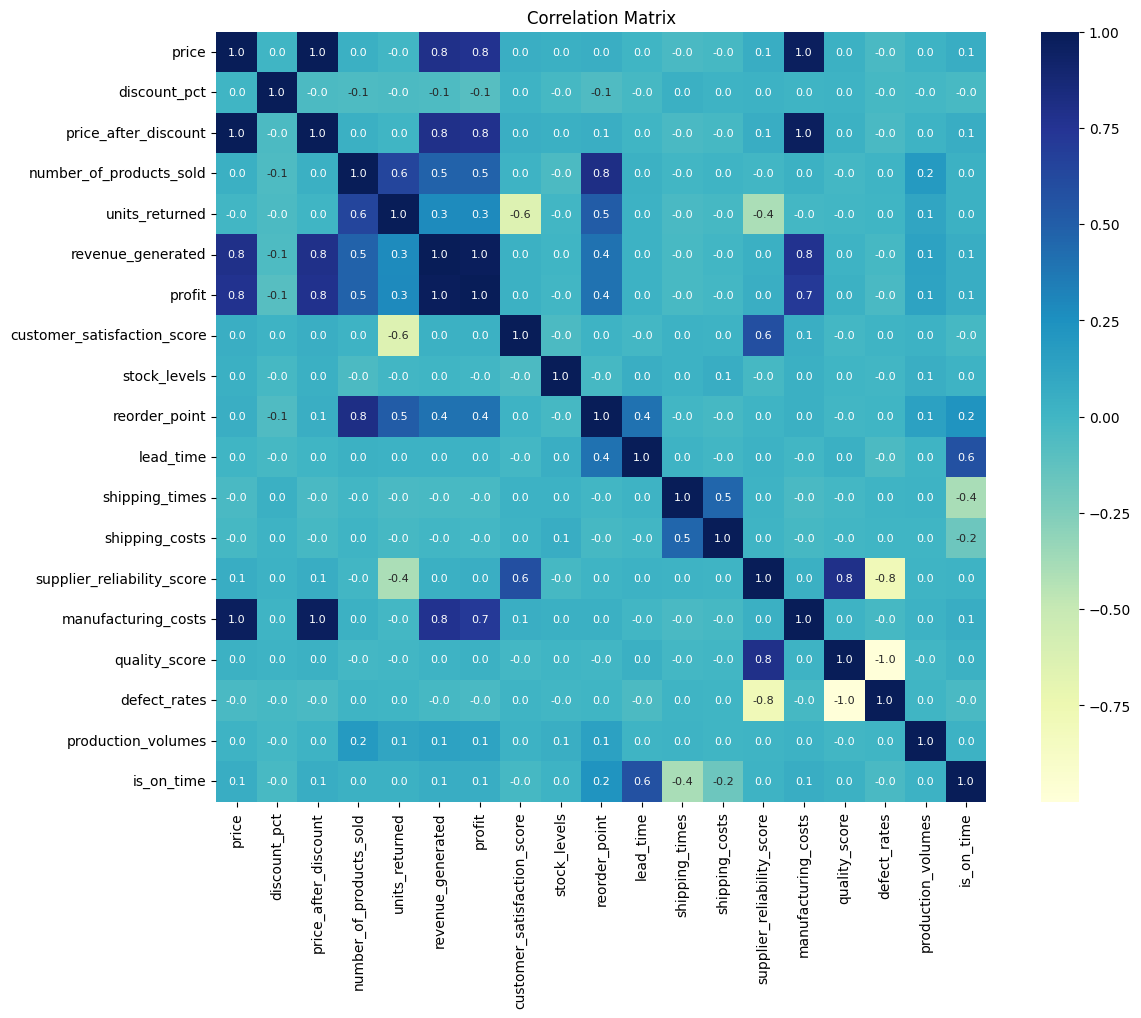

In [50]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr, cbar=True ,square=True , fmt=".1f" ,annot=True , annot_kws={"size":8}, cmap="YlGnBu"
)

plt.title("Correlation Matrix")
plt.show()

## Revenue Distribution

The distribution of revenue was analyzed to understand the spread of sales values across all orders.

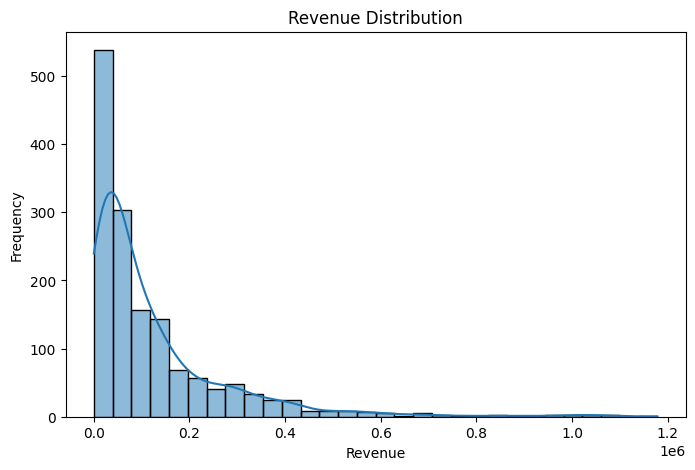

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="revenue_generated",
    bins=30,
    kde=True
)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

## Profit Distribution

The profit distribution was explored to identify the variability in profitability across orders.

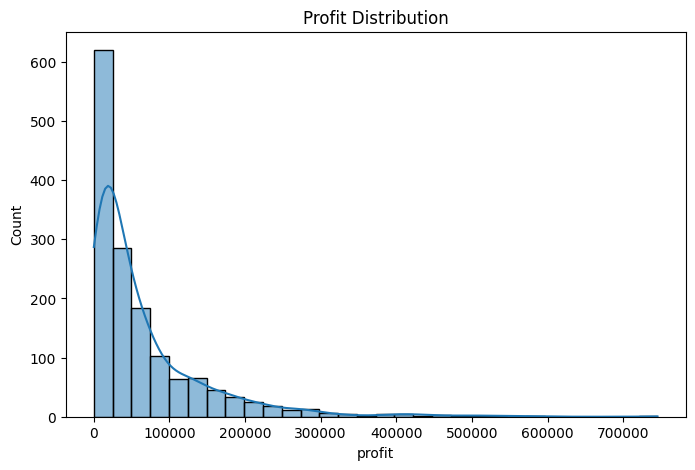

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="profit",
    bins=30,
    kde=True
)

plt.title("Profit Distribution")

plt.show()

## Revenue vs Profit

The relationship between revenue and profit was examined to evaluate business performance.

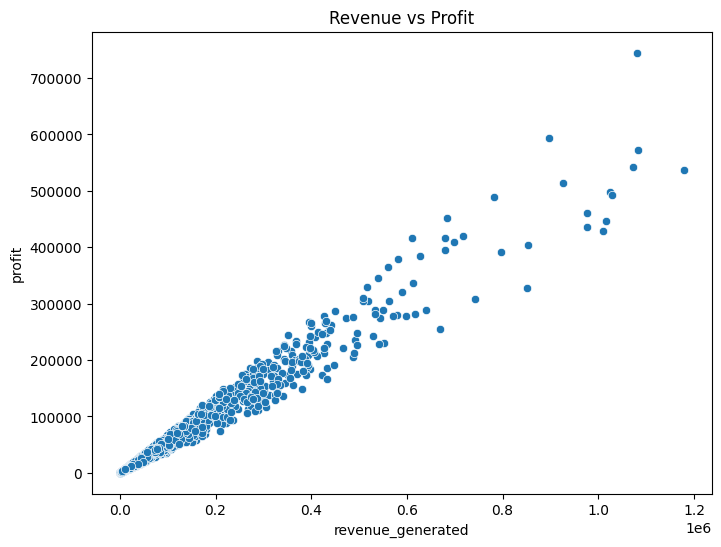

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="revenue_generated",
    y="profit"
)

plt.title("Revenue vs Profit")

plt.show()

## Orders by Region

Customer orders were analyzed across different regions to understand geographical demand.

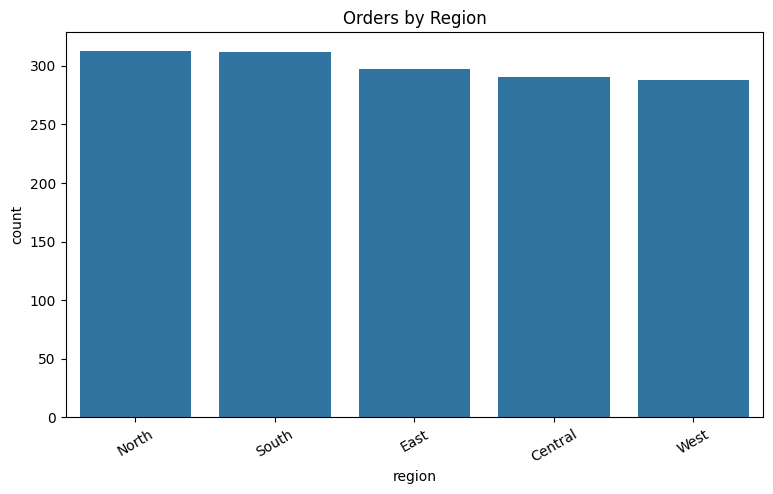

In [54]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="region",
    order=df["region"].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Orders by Region")

plt.show()

## Product Categories

The distribution of product categories was analyzed to understand the composition of products in the dataset.

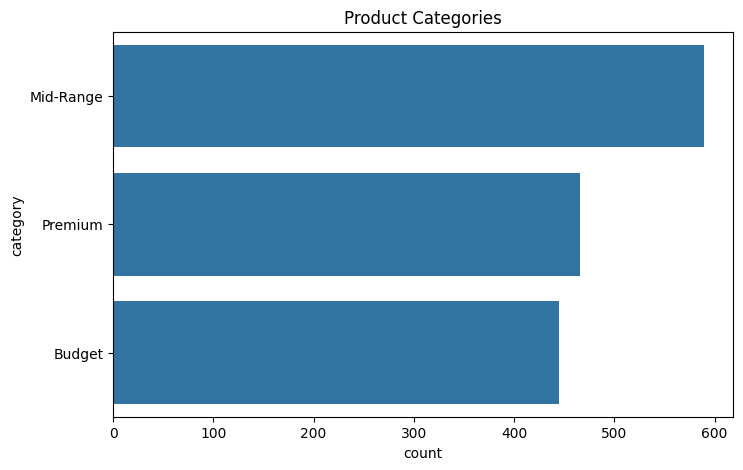

In [55]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index
)

plt.title("Product Categories")

plt.show()

## Customer Satisfaction

Customer satisfaction scores were analyzed to understand overall service quality.

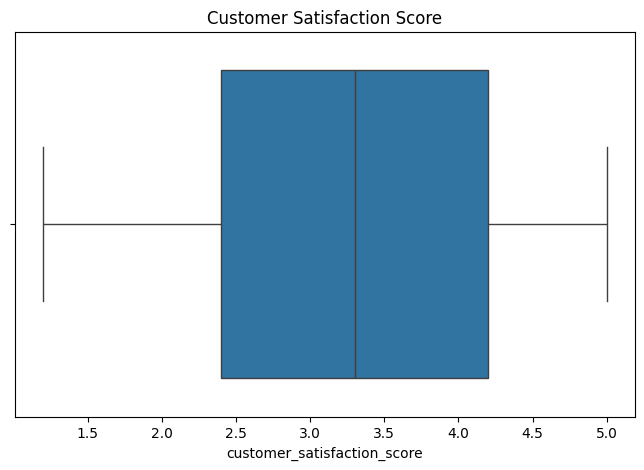

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="customer_satisfaction_score"
)

plt.title("Customer Satisfaction Score")

plt.show()

## Supplier Distribution

Supplier frequency was explored to understand supplier participation across orders.

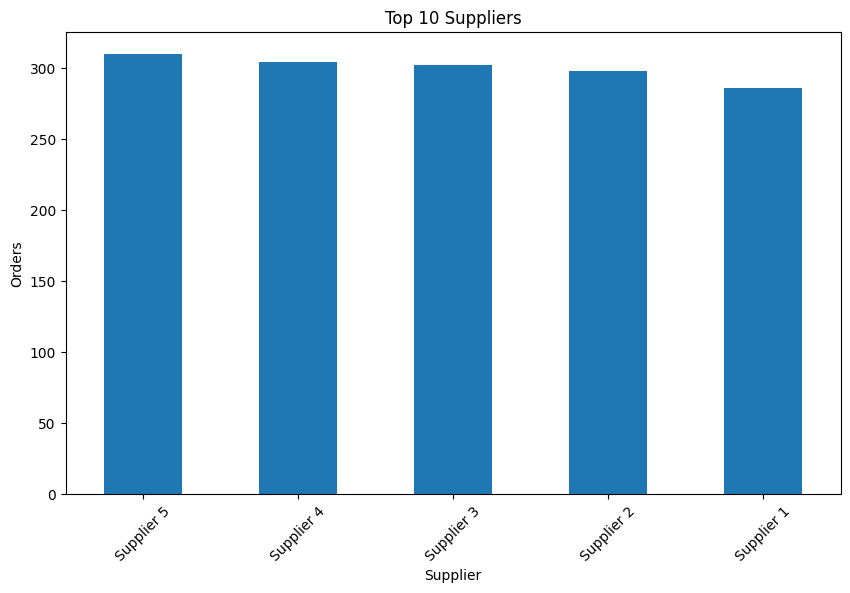

In [57]:
plt.figure(figsize=(10,6))

df["supplier_name"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Suppliers")

plt.xlabel("Supplier")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

## EDA Summary

The exploratory analysis provided a better understanding of the dataset by revealing data distributions, relationships between variables, and business patterns. These insights guided the data normalization process and supported the design of SQL analysis and Tableau dashboards.



---


# ***Data Normalization***

Data normalization is the process of organizing data into related tables to reduce redundancy, improve data integrity, and optimize database performance. The original flat dataset was transformed into a relational schema consisting of fact and dimension tables.

## Carrier Dimension

Carrier information was isolated into a separate table to simplify logistics analysis and remove repeated carrier details.

In [58]:
dim_carriers = df[['carrier_name']].drop_duplicates().reset_index(drop=True)
dim_carriers

,carrier_name
0,DHL
1,OnTrac
2,FedEx
3,UPS
4,Blue Dart
5,Aramex
6,USPS


In [59]:
dim_carriers = df.groupby('carrier_name')['is_on_time'].mean().reset_index()

In [60]:
dim_carriers

,carrier_name,is_on_time
0,Aramex,0.82
1,Blue Dart,0.67
2,DHL,0.83
3,FedEx,0.82
4,OnTrac,0.80
5,UPS,0.81
6,USPS,0.76


In [61]:
dim_carriers.insert(0, 'carrier_id', range(1, 1 + len(dim_carriers)))
dim_carriers

,carrier_id,carrier_name,is_on_time
0,1,Aramex,0.82
1,2,Blue Dart,0.67
2,3,DHL,0.83
3,4,FedEx,0.82
4,5,OnTrac,0.80
5,6,UPS,0.81
6,7,USPS,0.76


## Supplier Dimension

Supplier-related attributes were extracted into a separate dimension table to eliminate repeated supplier information across multiple orders.

In [62]:
dim_supplier = df.groupby('supplier_name').agg(
    avg_reliability_score=('supplier_reliability_score', 'mean'),
    avg_quality_score=('quality_score', 'mean'),
    avg_defect_rate_pct=('defect_rates', 'mean')
).reset_index()

In [63]:
dim_supplier = df.groupby('supplier_name').agg(
    avg_reliability_score=('supplier_reliability_score', 'mean'),
    avg_quality_score=('quality_score', 'mean'),
    avg_defect_rate_pct=('defect_rates', 'mean')
).reset_index()

In [64]:
dim_supplier.insert(0, 'supplier_id', range(1, 1 + len(dim_supplier)))
display(dim_supplier)

,supplier_id,supplier_name,avg_reliability_score,avg_quality_score,avg_defect_rate_pct
0,1,Supplier 1,0.66,51.29,4.87
1,2,Supplier 2,0.65,49.47,5.05
2,3,Supplier 3,0.66,50.77,4.92
3,4,Supplier 4,0.66,51.64,4.84
4,5,Supplier 5,0.64,48.09,5.19


## Product Dimension

Product information was separated into a dedicated dimension table containing product details and pricing attributes.

In [65]:
dim_products = df[[
    'sku',
    'product_type',
    'category',
    'price',
    'discount_pct',
    'price_after_discount',
    'manufacturing_costs'
]].drop_duplicates().reset_index(drop=True)
display(dim_products)

,sku,product_type,category,price,discount_pct,price_after_discount,manufacturing_costs
0,SKU0000,Smartphones,Premium,"1,159.56",13.92,998.15,477.03
1,SKU0001,Tablets,Premium,750.06,4.16,718.86,271.63
2,SKU0002,Laptops,Premium,"1,867.08",14.90,"1,588.89",969.25
3,SKU0003,Smartwatches,Premium,361.14,9.73,326.00,131.04
4,SKU0004,Laptops,Premium,"2,067.20",11.38,"1,831.95","1,132.55"
...,...,...,...,...,...,...,...
1495,SKU1495,Smartwatches,Mid-Range,307.63,6.63,287.23,115.37
1496,SKU1496,Smartphones,Premium,761.92,5.40,720.78,261.61
1497,SKU1497,Laptops,Premium,"1,797.29",8.57,"1,643.26",633.64
1498,SKU1498,Headphones,Budget,57.14,1.47,56.30,25.53


## Inventory Dimension

Inventory-related attributes were stored in a dedicated table to support stock monitoring and inventory analysis.

In [66]:
subdim_inventory = df[[
    'sku', 'stock_levels', 'reorder_point', 'stockout_risk', 'production_volumes'
]].drop_duplicates().reset_index(drop=True)

subdim_inventory['stockout_risk'] = subdim_inventory['stockout_risk'].apply(
    lambda x: 1 if x == 'Yes' else 0
)
print("subdim_inventory (Sub-Dimension of dim_products):")
display(subdim_inventory)

subdim_inventory (Sub-Dimension of dim_products):


,sku,stock_levels,reorder_point,stockout_risk,production_volumes
0,SKU0000,226,176,0,1084
1,SKU0001,254,97,0,372
2,SKU0002,291,336,1,558
3,SKU0003,130,305,1,537
4,SKU0004,151,195,1,1109
...,...,...,...,...,...
1495,SKU1495,292,283,0,679
1496,SKU1496,53,78,1,649
1497,SKU1497,20,262,1,572
1498,SKU1498,95,347,1,507


## Building the Fact Table

After creating the dimension tables, the original dataset was merged with the corresponding dimensions to retrieve the generated keys. This step establishes the relationships between the fact table and dimension tables, preparing the data for a normalized relational database.

In [67]:
df_merged = df.copy()
df_merged = df_merged.merge(dim_carriers, on='carrier_name', how='left')
df_merged = df_merged.merge(dim_supplier, on='supplier_name', how='left')
df_merged = df_merged.merge(
    dim_products,
    on=['sku', 'product_type', 'category', 'price',
        'discount_pct', 'price_after_discount', 'manufacturing_costs'],
    how='left'
)

## Fact Orders

The fact table contains transactional order records and connects all dimension tables through their corresponding keys, enabling efficient analytical queries.

In [68]:
fact_columns = [
    'order_id', 'order_date', 'ship_date', 'delivery_date',
    'sku', 'supplier_id', 'carrier_id',
    'customer_demographics', 'region', 'sales_channel', 'payment_method',
    'number_of_products_sold', 'units_returned', 'return_reason',
    'revenue_generated', 'profit', 'customer_satisfaction_score',
    'lead_time', 'shipping_times', 'shipping_costs',
    'supplier_reliability_score', 'quality_score', 'defect_rates',
    'transportation_mode', 'on_time_delivery'
]

fact_orders = df_merged[fact_columns].copy()

# Calculate total_cost and gross_margin_pct
fact_orders.loc[:, 'total_cost'] = (df_merged['manufacturing_costs'] * fact_orders['number_of_products_sold']) + fact_orders['shipping_costs']
fact_orders.loc[:, 'gross_margin_pct'] = round((fact_orders['profit'] / fact_orders['revenue_generated']) * 100, 2)

In [69]:
print("------------------- Fact Table Created Successfully -------------------")
fact_orders.info()

------------------- Fact Table Created Successfully -------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   order_id                     1500 non-null   object        
 1   order_date                   1500 non-null   datetime64[ns]
 2   ship_date                    1500 non-null   datetime64[ns]
 3   delivery_date                1500 non-null   datetime64[ns]
 4   sku                          1500 non-null   object        
 5   supplier_id                  1500 non-null   int64         
 6   carrier_id                   1500 non-null   int64         
 7   customer_demographics        1500 non-null   object        
 8   region                       1500 non-null   object        
 9   sales_channel                1500 non-null   object        
 10  payment_method               1500 no

## Data Model Verification

The normalized tables were reviewed to ensure correct relationships and prepare the dataset for SQL Server.

In [70]:
print("Fact Orders:", fact_orders.shape)
print("Products:", dim_products.shape)
print("Suppliers:", dim_supplier.shape)
print("Carriers:", dim_carriers.shape)
print("Inventory:", subdim_inventory.shape)

Fact Orders: (1500, 27)
Products: (1500, 7)
Suppliers: (5, 5)
Carriers: (7, 3)
Inventory: (1500, 5)


## Export Cleaned Tables

After completing the normalization process, each table was exported as a CSV file for import into SQL Server and further business analysis.

In [71]:
dim_supplier.to_csv('dim_supplier.csv', index=False)
dim_carriers.to_csv('dim_carriers.csv', index=False)
dim_products.to_csv('dim_products.csv', index=False)
subdim_inventory.to_csv('subdim_inventory.csv', index=False)
fact_orders.to_csv('fact_orders.csv', index=False)

## SQL Business Analysis

The normalized tables were imported into SQL Server to perform business analysis using SQL queries. The analysis focused on financial performance, inventory, supplier efficiency, logistics, customer behavior, and operational KPIs.

# ***Conclusion***

The dataset was successfully cleaned, transformed, normalized, and prepared for analysis. The processed data was imported into SQL Server for advanced business analysis and visualized through interactive Tableau dashboards, enabling data-driven decision-making.

# ***Phase 2:***
> **Analysis Questions Phase**

## 📊 Section 1: Financial Performance

### Q1. What is the overall financial performance summary, including total revenue, total profit, overall gross margin percentage, and average customer satisfaction score?

In [95]:
financial_summary = {
    'Total Revenue ($)':           fact_orders['revenue_generated'].sum(),
    'Total Profit ($)':            fact_orders['profit'].sum(),
    'Avg Gross Margin (%)':        (fact_orders['profit'].sum() / fact_orders['revenue_generated'].sum()) * 100,
    'Avg Customer Satisfaction':   fact_orders['customer_satisfaction_score'].mean()
}

for metric, value in financial_summary.items():
    if '%' in metric:
        print(f"  {metric}: {value:.2f}%")
    elif 'Satisfaction' in metric:
        print(f"  {metric}: {value:.2f} / 5.00")
    else:
        print(f"  {metric}: ${value:,.2f}")

  Total Revenue ($): $182,806,227.83
  Total Profit ($): $97,560,290.06
  Avg Gross Margin (%): 53.37%
  Avg Customer Satisfaction: 3.28 / 5.00


### Q2. How does monthly revenue trend across 2022–2024, and which month records the highest month-over-month growth rate within each year?

In [73]:
fact_orders['order_year']  = fact_orders['order_date'].dt.year
fact_orders['order_month'] = fact_orders['order_date'].dt.month

monthly_revenue = (
    fact_orders
    .groupby(['order_year', 'order_month'])['revenue_generated']
    .sum()
    .reset_index()
    .sort_values(['order_year', 'order_month'])
)

monthly_revenue['mom_change_pct'] = (
    monthly_revenue
    .groupby('order_year')['revenue_generated']
    .pct_change() * 100
).round(2)

best_months = (
    monthly_revenue.dropna(subset=['mom_change_pct'])
    .loc[
        monthly_revenue.dropna(subset=['mom_change_pct'])
        .groupby('order_year')['mom_change_pct']
        .idxmax()
    ]
)

print("Monthly Revenue with MoM Change (%):")
display(monthly_revenue)

print("\nBest Growth Month per Year:")
display(best_months[['order_year', 'order_month', 'revenue_generated', 'mom_change_pct']])

Monthly Revenue with MoM Change (%):


,order_year,order_month,revenue_generated,mom_change_pct
0,2022,1,"5,320,318.86",NaN
1,2022,2,"3,485,692.86",-34.48
2,2022,3,"5,774,522.67",65.66
3,2022,4,"4,562,954.63",-20.98
4,2022,5,"7,472,452.94",63.76
5,2022,6,"4,368,538.94",-41.54
6,2022,7,"5,971,886.13",36.70
7,2022,8,"4,894,715.69",-18.04
8,2022,9,"3,371,070.79",-31.13
9,2022,10,"6,560,538.61",94.61



Best Growth Month per Year:


,order_year,order_month,revenue_generated,mom_change_pct
9,2022,10,"6,560,538.61",94.61
18,2023,7,"5,961,270.79",78.26
27,2024,4,"6,116,443.04",107.67


### Q3. How is total revenue distributed across Q1–Q4, and does this seasonal pattern remain consistent across 2022, 2023, and 2024?

In [74]:
fact_orders['order_quarter'] = fact_orders['order_date'].dt.quarter

quarterly_overall = (
    fact_orders
    .groupby('order_quarter')['revenue_generated']
    .sum()
    .reset_index()
    .rename(columns={'revenue_generated': 'total_revenue'})
    .sort_values('total_revenue', ascending=False)
)

quarterly_by_year = (
    fact_orders
    .groupby(['order_year', 'order_quarter'])['revenue_generated']
    .sum()
    .unstack(level=0)
    .rename(columns=lambda y: f'Revenue_{int(y)}')
    .reset_index()
)

print("Overall Quarterly Revenue:")
display(quarterly_overall)

print("\nQuarterly Revenue Breakdown by Year:")
display(quarterly_by_year)

Overall Quarterly Revenue:


,order_quarter,total_revenue
3,4,"51,783,636.88"
2,3,"45,162,660.64"
1,2,"44,912,436.58"
0,1,"40,947,493.73"



Quarterly Revenue Breakdown by Year:


order_year,order_quarter,Revenue_2022,Revenue_2023,Revenue_2024
0,1,"14,580,534.39","14,785,279.52","11,581,679.82"
1,2,"16,403,946.51","11,679,194.23","16,829,295.84"
2,3,"14,237,672.61","16,918,440.64","14,006,547.39"
3,4,"14,935,623.89","17,297,205.90","19,550,807.09"


### Q4. Which customer demographic segment contributes the most to total revenue and profit, and how does average satisfaction score compare across segments?

In [75]:
demographic_analysis = fact_orders.groupby('customer_demographics').agg(
    total_revenue          = ('revenue_generated',          'sum'),
    total_profit           = ('profit',                     'sum'),
    avg_satisfaction       = ('customer_satisfaction_score','mean'),
    order_count            = ('order_id',                   'count')
).reset_index()

demographic_analysis['revenue_share_pct'] = (
    demographic_analysis['total_revenue'] / demographic_analysis['total_revenue'].sum() * 100
).round(2)

demographic_analysis['avg_satisfaction'] = demographic_analysis['avg_satisfaction'].round(2)

print("Revenue, Profit, and Satisfaction by Customer Segment:")
display(demographic_analysis.sort_values('total_revenue', ascending=False))

Revenue, Profit, and Satisfaction by Customer Segment:


,customer_demographics,total_revenue,total_profit,avg_satisfaction,order_count,revenue_share_pct
1,Male,"46,865,962.32","24,910,531.88",3.28,394,25.64
0,Female,"46,752,454.10","24,993,075.19",3.30,363,25.57
3,Unknown,"46,262,197.60","25,027,808.75",3.21,385,25.31
2,Non-Binary,"42,925,613.81","22,628,874.24",3.33,358,23.48


### Q5. How does total revenue, average selling price, average discount, and total units sold vary across product categories?

In [76]:
fact_with_cat = pd.merge(
    fact_orders,
    dim_products[['sku', 'category', 'price', 'discount_pct']],
    on='sku', how='left'
)

category_analysis = fact_with_cat.groupby('category').agg(
    total_revenue      = ('revenue_generated',        'sum'),
    avg_price          = ('price',                    'mean'),
    avg_discount_pct   = ('discount_pct',             'mean'),
    total_units_sold   = ('number_of_products_sold',  'sum')
).reset_index().sort_values('total_revenue', ascending=False)

print("Revenue & Pricing Analysis by Product Category:")
display(category_analysis)

Revenue & Pricing Analysis by Product Category:


,category,total_revenue,avg_price,avg_discount_pct,total_units_sold
2,Premium,"106,181,943.29",936.13,7.58,116928
1,Mid-Range,"59,795,920.22",434.14,7.34,150815
0,Budget,"16,828,364.32",179.87,7.80,107422


### Q6. Which sales channel achieves the highest average gross margin percentage, and how does total revenue volume compare across channels?

In [77]:
channel_analysis = fact_orders.groupby('sales_channel').agg(
    avg_gross_margin_pct = ('gross_margin_pct',   'mean'),
    total_revenue        = ('revenue_generated',  'sum'),
    order_count          = ('order_id',           'count')
).reset_index().sort_values('avg_gross_margin_pct', ascending=False)

channel_analysis['avg_gross_margin_pct'] = channel_analysis['avg_gross_margin_pct'].round(2)

highest = channel_analysis.iloc[0]
print(f"Highest Avg Gross Margin Channel: '{highest['sales_channel']}' at {highest['avg_gross_margin_pct']:.2f}%")
print()
display(channel_analysis)

Highest Avg Gross Margin Channel: 'Wholesale' at 53.91%



,sales_channel,avg_gross_margin_pct,total_revenue,order_count
4,Wholesale,53.91,"36,163,765.01",275
2,Online,53.53,"38,438,396.50",293
1,Direct Sales,52.77,"35,368,036.86",306
3,Retail Store,52.77,"35,598,128.55",308
0,B2B,51.35,"37,237,900.91",318


### Q7. Which geographic region contributes the highest share of total profit, and how does its revenue and average gross margin compare to other regions?

In [78]:
region_analysis = fact_orders.groupby('region').agg(
    total_profit         = ('profit',            'sum'),
    total_revenue        = ('revenue_generated', 'sum'),
    avg_gross_margin_pct = ('gross_margin_pct',  'mean')
).reset_index().sort_values('total_profit', ascending=False)

region_analysis['profit_share_pct'] = (
    region_analysis['total_profit'] / region_analysis['total_profit'].sum() * 100
).round(2)

region_analysis['avg_gross_margin_pct'] = region_analysis['avg_gross_margin_pct'].round(2)

top = region_analysis.iloc[0]
print(f"Highest Profit Region: '{top['region']}' — Profit ${top['total_profit']:,.2f} ({top['profit_share_pct']:.2f}% of total)")
print()
display(region_analysis)

Highest Profit Region: 'North' — Profit $20,860,384.47 (21.38% of total)



,region,total_profit,total_revenue,avg_gross_margin_pct,profit_share_pct
2,North,"20,860,384.47","38,859,122.84",53.22,21.38
4,West,"19,860,532.61","37,391,446.44",52.35,20.36
0,Central,"18,987,805.78","35,992,862.48",52.94,19.46
3,South,"18,973,735.83","35,563,438.54",53.36,19.45
1,East,"18,877,831.37","34,999,357.53",52.20,19.35


### Q8. What is the average discount percentage applied per product category, and how does it relate to the average price and profit margin within each category?

In [79]:
discount_analysis = fact_with_cat.groupby('category').agg(
    avg_discount_pct     = ('discount_pct',      'mean'),
    avg_price            = ('price',             'mean'),
    avg_gross_margin_pct = ('gross_margin_pct',  'mean')
).reset_index().sort_values('avg_discount_pct', ascending=False)

discount_analysis = discount_analysis.round(2)

print("Discount vs Price vs Gross Margin by Category:")
display(discount_analysis)

Discount vs Price vs Gross Margin by Category:


,category,avg_discount_pct,avg_price,avg_gross_margin_pct
0,Budget,7.80,179.87,52.25
2,Premium,7.58,936.13,53.10
1,Mid-Range,7.34,434.14,53.05


### Q9. Which product type has the highest average manufacturing cost relative to its selling price, and how does this cost-to-price ratio affect profitability?

In [80]:
product_cost = dim_products.groupby('product_type').agg(
    avg_manufacturing_cost = ('manufacturing_costs', 'mean'),
    avg_selling_price      = ('price',              'mean')
).reset_index()

product_cost['cost_to_price_ratio'] = (
    product_cost['avg_manufacturing_cost'] / product_cost['avg_selling_price']
).round(4)

# Merge gross margin from fact_orders for context
product_margin = pd.merge(
    fact_orders,
    dim_products[['sku', 'product_type']],
    on='sku', how='left'
).groupby('product_type')['gross_margin_pct'].mean().reset_index()
product_margin.rename(columns={'gross_margin_pct': 'avg_gross_margin_pct'}, inplace=True)

product_cost = pd.merge(product_cost, product_margin, on='product_type', how='left')
product_cost['avg_gross_margin_pct'] = product_cost['avg_gross_margin_pct'].round(2)

highest = product_cost.loc[product_cost['cost_to_price_ratio'].idxmax()]
print(f"Highest Cost-to-Price Ratio: '{highest['product_type']}' at {highest['cost_to_price_ratio']:.4f}")
print()
display(product_cost.sort_values('cost_to_price_ratio', ascending=False))

Highest Cost-to-Price Ratio: 'Headphones' at 0.4360



,product_type,avg_manufacturing_cost,avg_selling_price,cost_to_price_ratio,avg_gross_margin_pct
0,Headphones,73.87,169.42,0.44,51.59
1,Laptops,472.80,"1,084.37",0.44,52.93
4,Tablets,208.85,483.39,0.43,53.29
3,Smartwatches,130.99,306.39,0.43,53.03
2,Smartphones,197.96,470.40,0.42,53.21


### Q10. Which payment method is associated with the highest average revenue per order, and which payment method accounts for the highest total order volume?

In [81]:
payment_analysis = fact_orders.groupby('payment_method').agg(
    avg_revenue_per_order = ('revenue_generated', 'mean'),
    total_revenue         = ('revenue_generated', 'sum'),
    total_orders          = ('order_id',          'count')
).reset_index().sort_values('avg_revenue_per_order', ascending=False)

payment_analysis['avg_revenue_per_order'] = payment_analysis['avg_revenue_per_order'].round(2)

top_avg = payment_analysis.iloc[0]
top_vol = payment_analysis.sort_values('total_orders', ascending=False).iloc[0]

print(f"Highest Avg Revenue per Order: '{top_avg['payment_method']}' — ${top_avg['avg_revenue_per_order']:,.2f}")
print(f"Highest Order Volume: '{top_vol['payment_method']}' — {int(top_vol['total_orders'])} orders")
print()
display(payment_analysis)

Highest Avg Revenue per Order: 'Credit Card' — $129,925.73
Highest Order Volume: 'Invoice' — 312 orders



,payment_method,avg_revenue_per_order,total_revenue,total_orders
2,Credit Card,"129,925.73","37,678,460.30",290
0,Bank Transfer,"122,997.39","35,423,249.08",288
3,Digital Wallet,"120,913.35","37,483,139.24",310
4,Invoice,"120,701.90","37,658,993.72",312
1,Cash,"115,207.95","34,562,385.49",300


---
## 🏭 Section 2: Supplier Performance

### Q11. Which suppliers demonstrate the best overall performance based on reliability score, quality score, defect rate, average lead time, and total profit contribution?

In [82]:
fact_orders['order_processing_time'] = (
    fact_orders['ship_date'] - fact_orders['order_date']
).dt.days

supplier_ops = fact_orders.groupby('supplier_id').agg(
    avg_lead_time           = ('lead_time',              'mean'),
    avg_processing_time     = ('order_processing_time',  'mean'),
    total_profit            = ('profit',                 'sum')
).reset_index()

supplier_full = pd.merge(supplier_ops, dim_supplier, on='supplier_id', how='left')
supplier_full = supplier_full.round(2)

print("Supplier Overall Performance Scoreboard:")
display(
    supplier_full[[
        'supplier_name', 'avg_reliability_score', 'avg_quality_score',
        'avg_defect_rate_pct', 'avg_lead_time', 'avg_processing_time', 'total_profit'
    ]].sort_values('avg_reliability_score', ascending=False)
)

Supplier Overall Performance Scoreboard:


,supplier_name,avg_reliability_score,avg_quality_score,avg_defect_rate_pct,avg_lead_time,avg_processing_time,total_profit
0,Supplier 1,0.66,51.29,4.87,13.62,2.85,"18,866,529.52"
2,Supplier 3,0.66,50.77,4.92,13.65,2.99,"19,194,869.71"
3,Supplier 4,0.66,51.64,4.84,13.89,3.21,"18,418,601.92"
1,Supplier 2,0.65,49.47,5.05,12.89,3.05,"21,071,663.21"
4,Supplier 5,0.64,48.09,5.19,13.39,3.00,"20,008,625.70"


### Q12. What is the total revenue lost due to returned units per supplier, and is there a noticeable correlation with each supplier's average defect rate?

In [83]:
df_rev_lost = pd.merge(
    fact_orders,
    dim_products[['sku', 'price_after_discount']],
    on='sku', how='left'
)
df_rev_lost['revenue_lost'] = df_rev_lost['units_returned'] * df_rev_lost['price_after_discount']

supplier_loss = (
    df_rev_lost.groupby('supplier_id')['revenue_lost']
    .sum()
    .reset_index()
)
supplier_loss = pd.merge(
    supplier_loss,
    dim_supplier[['supplier_id', 'supplier_name', 'avg_defect_rate_pct']],
    on='supplier_id', how='left'
)

print("Revenue Lost vs. Defect Rate per Supplier:")
display(supplier_loss.sort_values('revenue_lost', ascending=False))

# Simple correlation
corr = supplier_loss[['revenue_lost', 'avg_defect_rate_pct']].corr().iloc[0, 1]
print(f"\nPearson Correlation (Revenue Lost vs Defect Rate): {corr:.4f}")

Revenue Lost vs. Defect Rate per Supplier:


,supplier_id,revenue_lost,supplier_name,avg_defect_rate_pct
4,5,"2,945,840.02",Supplier 5,5.19
1,2,"2,712,356.01",Supplier 2,5.05
2,3,"2,613,391.05",Supplier 3,4.92
0,1,"2,559,005.54",Supplier 1,4.87
3,4,"2,280,220.93",Supplier 4,4.84



Pearson Correlation (Revenue Lost vs Defect Rate): 0.9301


---
## 🚚 Section 3: Logistics & Operations

### Q13. What is the on-time delivery rate (%) for each carrier, and which carrier offers the best balance between delivery reliability and average shipping cost?

In [84]:
carrier_cost = fact_orders.groupby('carrier_id')['shipping_costs'].mean().reset_index()
carrier_cost.rename(columns={'shipping_costs': 'avg_shipping_cost'}, inplace=True)

carrier_full = pd.merge(dim_carriers, carrier_cost, on='carrier_id', how='left')
carrier_full['on_time_rate_pct'] = (carrier_full['is_on_time'] * 100).round(2)
carrier_full['avg_shipping_cost'] = carrier_full['avg_shipping_cost'].round(2)

print("Carrier On-Time Delivery Rate vs. Avg Shipping Cost:")
display(
    carrier_full[['carrier_name', 'on_time_rate_pct', 'avg_shipping_cost']]
    .sort_values('on_time_rate_pct', ascending=False)
)

Carrier On-Time Delivery Rate vs. Avg Shipping Cost:


,carrier_name,on_time_rate_pct,avg_shipping_cost
2,DHL,83.45,177.05
0,Aramex,82.20,170.52
3,FedEx,81.64,151.30
5,UPS,80.53,168.13
4,OnTrac,80.00,202.19
6,USPS,76.19,179.09
1,Blue Dart,66.67,166.74


### Q14. What is the average transit time per transportation mode — and does air freight show a longer average transit time than sea freight in this dataset? What might explain this anomaly?

In [85]:
fact_orders['transit_time'] = (fact_orders['delivery_date'] - fact_orders['ship_date']).dt.days

transit_analysis = fact_orders.groupby('transportation_mode').agg(
    avg_transit_days = ('transit_time', 'mean'),
    min_transit      = ('transit_time', 'min'),
    max_transit      = ('transit_time', 'max'),
    order_count      = ('order_id',     'count')
).reset_index().sort_values('avg_transit_days', ascending=False)

transit_analysis['avg_transit_days'] = transit_analysis['avg_transit_days'].round(2)

print("Average Transit Time per Transportation Mode:")
display(transit_analysis)

air_avg = transit_analysis.loc[transit_analysis['transportation_mode'] == 'Air', 'avg_transit_days'].values
sea_avg = transit_analysis.loc[transit_analysis['transportation_mode'] == 'Sea', 'avg_transit_days'].values

if len(air_avg) and len(sea_avg) and air_avg[0] > sea_avg[0]:
    print(f"\n⚠️ Anomaly Detected: Air avg ({air_avg[0]:.2f} days) > Sea avg ({sea_avg[0]:.2f} days).")
    print("   This may reflect long-distance international air routes or data entry patterns worth investigating.")

Average Transit Time per Transportation Mode:


,transportation_mode,avg_transit_days,min_transit,max_transit,order_count
0,Air,9.20,2,13,461
2,Sea,6.85,1,13,468
1,Road,5.16,1,13,571



⚠️ Anomaly Detected: Air avg (9.20 days) > Sea avg (6.85 days).
   This may reflect long-distance international air routes or data entry patterns worth investigating.


### Q15. What is the average shipping cost per carrier, and how does cost rank compare to each carrier's on-time delivery performance?

In [86]:
carrier_shipping = fact_orders.groupby('carrier_id')['shipping_costs'].mean().reset_index()
carrier_shipping.rename(columns={'shipping_costs': 'avg_shipping_cost'}, inplace=True)

carrier_cost_perf = pd.merge(
    pd.merge(carrier_shipping, dim_carriers, on='carrier_id', how='left'),
    carrier_full[['carrier_name', 'on_time_rate_pct']],
    on='carrier_name', how='left'
)

carrier_cost_perf['avg_shipping_cost'] = carrier_cost_perf['avg_shipping_cost'].round(2)

print("Avg Shipping Cost vs. On-Time Rate per Carrier:")
display(
    carrier_cost_perf[['carrier_name', 'avg_shipping_cost', 'on_time_rate_pct']]
    .sort_values('avg_shipping_cost', ascending=False)
)

Avg Shipping Cost vs. On-Time Rate per Carrier:


,carrier_name,avg_shipping_cost,on_time_rate_pct
4,OnTrac,202.19,80.00
6,USPS,179.09,76.19
2,DHL,177.05,83.45
0,Aramex,170.52,82.20
5,UPS,168.13,80.53
1,Blue Dart,166.74,66.67
3,FedEx,151.30,81.64


### Q16. How does average customer satisfaction score differ between on-time and late deliveries, and what is the magnitude of this impact?

In [87]:
satisfaction_delivery = fact_orders.groupby('on_time_delivery').agg(
    avg_satisfaction = ('customer_satisfaction_score', 'mean'),
    order_count      = ('order_id',                   'count')
).reset_index()

satisfaction_delivery['avg_satisfaction'] = satisfaction_delivery['avg_satisfaction'].round(2)

on_time_score = satisfaction_delivery.loc[satisfaction_delivery['on_time_delivery'] == 'Yes', 'avg_satisfaction'].values
late_score    = satisfaction_delivery.loc[satisfaction_delivery['on_time_delivery'] == 'No',  'avg_satisfaction'].values

print("Avg Customer Satisfaction: On-Time vs. Late Deliveries")
display(satisfaction_delivery)

if len(on_time_score) and len(late_score):
    diff = on_time_score[0] - late_score[0]
    print(f"\nSatisfaction Gap (On-Time − Late): {diff:.2f} points")

Avg Customer Satisfaction: On-Time vs. Late Deliveries


,on_time_delivery,avg_satisfaction,order_count
0,No,3.31,294
1,Yes,3.27,1206



Satisfaction Gap (On-Time − Late): -0.04 points


### Q17. Which region incurs the highest total shipping costs, and how does shipping cost per order compare across regions?

In [88]:
region_shipping = fact_orders.groupby('region').agg(
    total_shipping_cost     = ('shipping_costs', 'sum'),
    avg_shipping_cost_order = ('shipping_costs', 'mean'),
    order_count             = ('order_id',       'count')
).reset_index().sort_values('total_shipping_cost', ascending=False)

region_shipping['avg_shipping_cost_order'] = region_shipping['avg_shipping_cost_order'].round(2)

top = region_shipping.iloc[0]
print(f"Highest Total Shipping Cost Region: '{top['region']}' — ${top['total_shipping_cost']:,.2f}")
print()
display(region_shipping)

Highest Total Shipping Cost Region: 'South' — $53,087.48



,region,total_shipping_cost,avg_shipping_cost_order,order_count
3,South,"53,087.48",170.15,312
0,Central,"52,166.83",179.89,290
2,North,"49,424.77",157.91,313
1,East,"49,028.29",165.08,297
4,West,"48,077.19",166.93,288


---
## 📦 Section 4: Returns & Inventory

### Q18. Which product category has the highest return rate (units returned ÷ units sold), and what is the most frequent return reason associated with it?

In [89]:
df_returns = pd.merge(fact_orders, dim_products[['sku', 'category']], on='sku', how='left')

return_rates = df_returns.groupby('category').agg(
    total_units_returned = ('units_returned',           'sum'),
    total_units_sold     = ('number_of_products_sold',  'sum')
).reset_index()

return_rates['return_rate_pct'] = (
    return_rates['total_units_returned'] / return_rates['total_units_sold'] * 100
).round(2)

top_reason = (
    df_returns[df_returns['return_reason'] != 'Not Returned']
    .groupby(['category', 'return_reason'])['units_returned']
    .sum()
    .reset_index()
    .sort_values('units_returned', ascending=False)
    .groupby('category')
    .first()
    .reset_index()
    .rename(columns={'return_reason': 'top_return_reason', 'units_returned': 'top_reason_units'})
)

result = pd.merge(return_rates, top_reason[['category', 'top_return_reason', 'top_reason_units']], on='category', how='left')

print("Return Rate & Top Return Reason per Product Category:")
display(result.sort_values('return_rate_pct', ascending=False))

Return Rate & Top Return Reason per Product Category:


,category,total_units_returned,total_units_sold,return_rate_pct,top_return_reason,top_reason_units
0,Budget,8427,107422,7.84,Defective,2969
1,Mid-Range,10923,150815,7.24,Defective,3612
2,Premium,8210,116928,7.02,Defective,3007


### Q19. What is the most common return reason across all returned orders, and how is it distributed across product categories?

In [90]:
returned_orders = fact_orders[fact_orders['return_reason'] != 'Not Returned']

overall_reasons = (
    returned_orders['return_reason']
    .value_counts()
    .reset_index()
)
overall_reasons.columns = ['return_reason', 'count']
overall_reasons['share_pct'] = (overall_reasons['count'] / overall_reasons['count'].sum() * 100).round(2)

top_reason = overall_reasons.iloc[0]
print(f"Most Common Return Reason: '{top_reason['return_reason']}' — {int(top_reason['count'])} occurrences ({top_reason['share_pct']:.2f}%)")
print()
print("Full Return Reason Distribution:")
display(overall_reasons)

Most Common Return Reason: 'Defective' — 513 occurrences (35.14%)

Full Return Reason Distribution:


,return_reason,count,share_pct
0,Defective,513,35.14
1,Not As Described,267,18.29
2,Changed Mind,252,17.26
3,Wrong Item,224,15.34
4,Damaged In Shipping,204,13.97


### Q20. How many SKUs are currently flagged as stockout risk, and which product types are most affected?

In [91]:
skus_at_risk = subdim_inventory[subdim_inventory['stockout_risk'] == 1].copy()

skus_at_risk_with_type = pd.merge(
    skus_at_risk,
    dim_products[['sku', 'product_type', 'category']],
    on='sku', how='left'
)

total_at_risk = len(skus_at_risk)
risk_by_type = (
    skus_at_risk_with_type
    .groupby('product_type')['sku']
    .count()
    .reset_index()
    .rename(columns={'sku': 'sku_count_at_risk'})
    .sort_values('sku_count_at_risk', ascending=False)
)

print(f"Total SKUs Flagged as Stockout Risk: {total_at_risk}")
print()
print("Stockout Risk SKUs by Product Type:")
display(risk_by_type)

Total SKUs Flagged as Stockout Risk: 831

Stockout Risk SKUs by Product Type:


,product_type,sku_count_at_risk
2,Smartphones,210
4,Tablets,175
0,Headphones,163
1,Laptops,158
3,Smartwatches,125


### Q21. Which product type has the highest average defect rate, and does it also have the highest return rate?

In [92]:
product_defect = pd.merge(
    fact_orders, dim_products[['sku', 'product_type']], on='sku', how='left'
)

defect_analysis = product_defect.groupby('product_type').agg(
    avg_defect_rate_pct  = ('defect_rates',              'mean'),
    total_units_returned = ('units_returned',            'sum'),
    total_units_sold     = ('number_of_products_sold',   'sum')
).reset_index()

defect_analysis['return_rate_pct'] = (
    defect_analysis['total_units_returned'] / defect_analysis['total_units_sold'] * 100
).round(2)
defect_analysis['avg_defect_rate_pct'] = defect_analysis['avg_defect_rate_pct'].round(2)

top_defect = defect_analysis.loc[defect_analysis['avg_defect_rate_pct'].idxmax()]
print(f"Highest Avg Defect Rate: '{top_defect['product_type']}' at {top_defect['avg_defect_rate_pct']:.2f}%")
print()
display(defect_analysis.sort_values('avg_defect_rate_pct', ascending=False))

Highest Avg Defect Rate: 'Smartwatches' at 5.42%



,product_type,avg_defect_rate_pct,total_units_returned,total_units_sold,return_rate_pct
3,Smartwatches,5.42,4223,58678,7.20
4,Tablets,5.12,5589,77216,7.24
0,Headphones,4.94,5169,70391,7.34
2,Smartphones,4.82,7157,94306,7.59
1,Laptops,4.73,5422,74574,7.27


### Q22. Which product type generates the highest total number of units sold, and what is its share of total sales volume?

In [93]:
product_units = pd.merge(
    fact_orders, dim_products[['sku', 'product_type']], on='sku', how='left'
)

units_agg = product_units.groupby('product_type').agg(
    total_units_sold = ('number_of_products_sold', 'sum')
).reset_index()

units_agg['sales_share_pct'] = (
    units_agg['total_units_sold'] / units_agg['total_units_sold'].sum() * 100
).round(2)

top = units_agg.loc[units_agg['total_units_sold'].idxmax()]
print(f"Highest Units Sold: '{top['product_type']}' — {int(top['total_units_sold']):,} units ({top['sales_share_pct']:.2f}% of total)")
print()
display(units_agg.sort_values('total_units_sold', ascending=False))

Highest Units Sold: 'Smartphones' — 94,306 units (25.14% of total)



,product_type,total_units_sold,sales_share_pct
2,Smartphones,94306,25.14
4,Tablets,77216,20.58
1,Laptops,74574,19.88
0,Headphones,70391,18.76
3,Smartwatches,58678,15.64
